In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import os
# print(os.getcwd())

In [2]:

csv_path = "../data/results/final_merged/mill.csv"
df = pd.read_csv(csv_path) 

df.columns = df.columns.str.strip()

In [3]:
# Ensure correct dtypes
bool_cols = ["judge_answer_correctness_vs_ref", "judge_answer_helpfulness"]
for col in bool_cols:
    if df[col].dtype != bool:
        df[col] = df[col].astype(str).str.lower().isin(["true", "1", "yes"])

numeric_cols = ["meta_total_tokens"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [4]:

# --- Clean up total_elapsed_time column ---
def parse_seconds(x):
    """Convert strings like '12 seconds' or '1.5 s' to float seconds."""
    if pd.isna(x):
        return None
    import re
    match = re.search(r"([\d\.]+)", str(x))
    return float(match.group(1)) if match else None

df["total_elapsed_time_sec"] = df["total_elapsed_time"].apply(parse_seconds)


# --- ESTIMATED price per run ---
def compute_price(row):
    """
    Compute cost (in USD) based on model type and total tokens.
    Prices per 1M tokens:
      gpt-nano: $0.40
      gpt-mini: $2.00
    """
    tokens = row.get("meta_total_tokens", 0)
    model = str(row.get("model", "")).lower()
    
    if "nano" in model:
        price_per_million = 0.40
    elif "mini" in model:
        price_per_million = 2.00
    else:
        # Default if model not recognized
        price_per_million = 1.00  

    return (tokens / 1_000_000) * price_per_million

df["price_usd"] = df.apply(compute_price, axis=1)

# --- Group and Aggregate ---
group_cols = ["approach", "model", "top_k"]

agg_df = (
    df.groupby(group_cols)
      .agg(
          avg_meta_total_tokens=("meta_total_tokens", "mean"),
          avg_price_usd=("price_usd", "mean"),
          avg_latency_sec=("total_elapsed_time_sec", "mean"),
          true_correctness_count=("judge_answer_correctness_vs_ref", "sum"),
          total_correctness_count=("judge_answer_correctness_vs_ref", "count"),
          true_helpfulness_count=("judge_answer_helpfulness", "sum"),
          total_helpfulness_count=("judge_answer_helpfulness", "count"),
      )
      .reset_index()
)

In [5]:
# Add percentage columns
agg_df["pct_correctness_true"] = (
    agg_df["true_correctness_count"] / agg_df["total_correctness_count"] * 100
)
agg_df["pct_helpfulness_true"] = (
    agg_df["true_helpfulness_count"] / agg_df["total_helpfulness_count"] * 100
)

In [6]:

# --- Summary ---
print("Summary of metrics by (approach, model, top_k):")
display(agg_df)

Summary of metrics by (approach, model, top_k):


,approach,model,top_k,avg_meta_total_tokens,avg_price_usd,avg_latency_sec,true_correctness_count,total_correctness_count,true_helpfulness_count,total_helpfulness_count,pct_correctness_true,pct_helpfulness_true
0,graph_eager,gpt-5-mini-2025-08-07,3,1906.117647,0.003812,6.853137,15,102,18,102,14.705882,17.647059
1,graph_eager,gpt-5-mini-2025-08-07,7,1902.156863,0.003804,6.476961,14,102,21,102,13.725490,20.588235
2,graph_eager,gpt-5-nano-2025-08-07,3,1920.607843,0.000768,5.301667,13,102,17,102,12.745098,16.666667
3,graph_eager,gpt-5-nano-2025-08-07,7,1919.215686,0.000768,5.950196,12,102,17,102,11.764706,16.666667
4,graph_mmr,gpt-5-mini-2025-08-07,3,3225.784314,0.006452,7.174804,25,102,31,102,24.509804,30.392157
5,graph_mmr,gpt-5-mini-2025-08-07,7,3226.098039,0.006452,8.001569,26,102,30,102,25.490196,29.411765
6,graph_mmr,gpt-5-nano-2025-08-07,3,3207.852941,0.001283,6.164804,25,102,25,102,24.509804,24.509804
7,graph_mmr,gpt-5-nano-2025-08-07,7,3199.549020,0.001280,5.980784,25,102,27,102,24.509804,26.470588
8,lc_bm25,gpt-5-mini-2025-08-07,3,11752.078431,0.023504,5.944118,50,102,56,102,49.019608,54.901961
9,lc_bm25,gpt-5-mini-2025-08-07,7,27105.274510,0.054211,6.595882,58,102,67,102,56.862745,65.686275


In [7]:

# --- Heatmap comparison ---
heatmap_df = (
    agg_df.groupby(["approach", "model"])
    [["pct_correctness_true", "pct_helpfulness_true"]]
    .mean()
    .reset_index()
)

In [8]:
# =======================================
# Section 8: Evaluate Best Combinations
# =======================================

# Sort and display top combinations by correctness
best_correctness = agg_df.sort_values("pct_correctness_true", ascending=False)
best_helpfulness = agg_df.sort_values("pct_helpfulness_true", ascending=False)

print("\nTop combinations by % Correctness TRUE:")
display(best_correctness[[
    "approach", "model", "top_k", 
    "pct_correctness_true",
]])

print("\nTop combinations by % Helpfulness TRUE:")
display(best_helpfulness[[
    "approach", "model", "top_k", 
    "pct_helpfulness_true",
]])


Top combinations by % Correctness TRUE:


,approach,model,top_k,pct_correctness_true
12,openai_keyword,gpt-5-mini-2025-08-07,3,67.647059
17,openai_semantic,gpt-5-mini-2025-08-07,7,64.705882
16,openai_semantic,gpt-5-mini-2025-08-07,3,62.745098
13,openai_keyword,gpt-5-mini-2025-08-07,7,59.803922
9,lc_bm25,gpt-5-mini-2025-08-07,7,56.862745
21,vanilla,gpt-5-mini-2025-08-07,7,49.019608
8,lc_bm25,gpt-5-mini-2025-08-07,3,49.019608
15,openai_keyword,gpt-5-nano-2025-08-07,7,48.039216
14,openai_keyword,gpt-5-nano-2025-08-07,3,47.058824
18,openai_semantic,gpt-5-nano-2025-08-07,3,45.098039



Top combinations by % Helpfulness TRUE:


,approach,model,top_k,pct_helpfulness_true
12,openai_keyword,gpt-5-mini-2025-08-07,3,74.509804
13,openai_keyword,gpt-5-mini-2025-08-07,7,74.509804
16,openai_semantic,gpt-5-mini-2025-08-07,3,72.549020
17,openai_semantic,gpt-5-mini-2025-08-07,7,68.627451
9,lc_bm25,gpt-5-mini-2025-08-07,7,65.686275
21,vanilla,gpt-5-mini-2025-08-07,7,59.803922
18,openai_semantic,gpt-5-nano-2025-08-07,3,58.823529
14,openai_keyword,gpt-5-nano-2025-08-07,3,56.862745
19,openai_semantic,gpt-5-nano-2025-08-07,7,56.862745
8,lc_bm25,gpt-5-mini-2025-08-07,3,54.901961


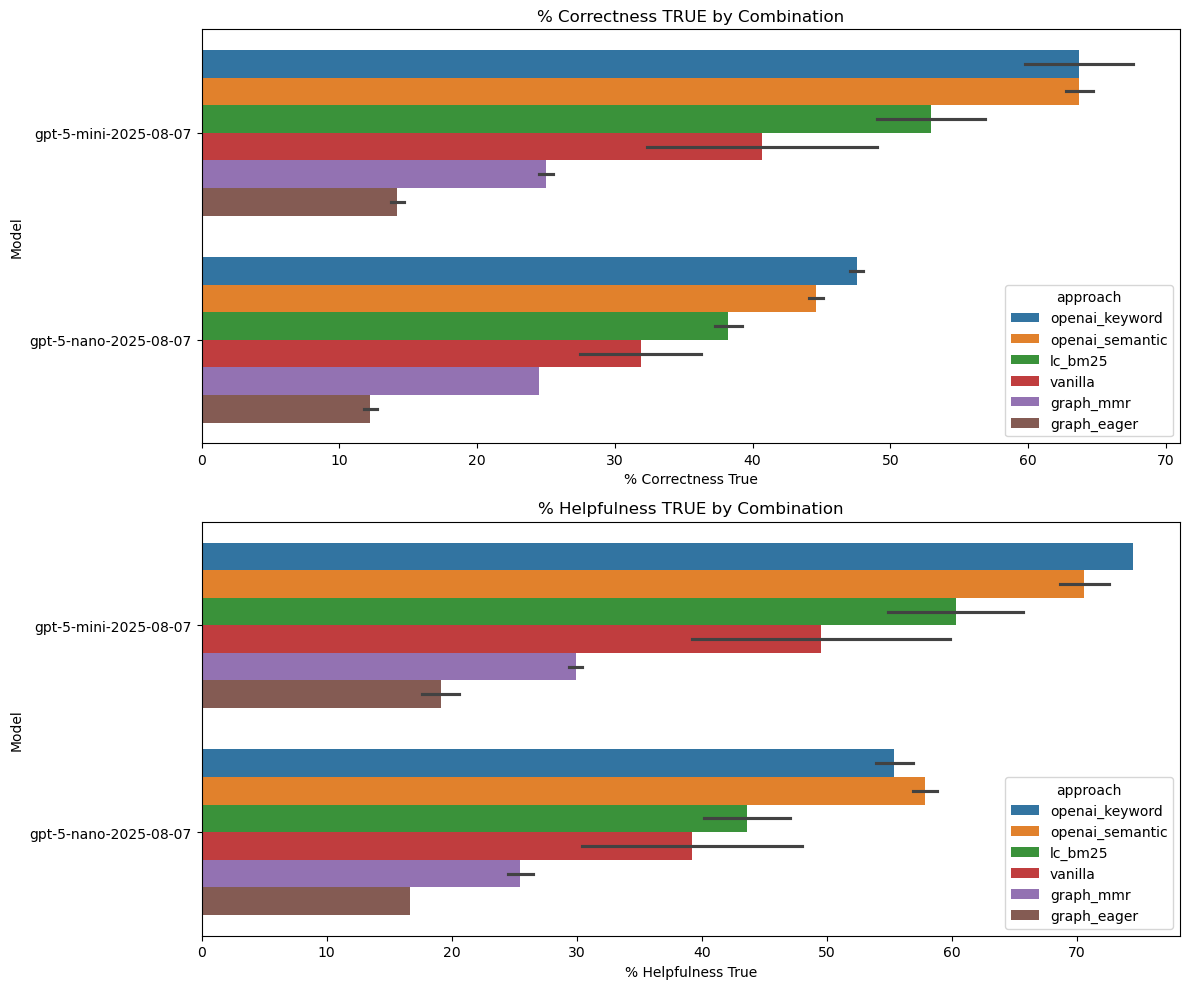

In [9]:
# =======================================
# Visual Comparison Bar Charts
# =======================================

# Combine metrics in one figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
sns.barplot(
    data=agg_df.sort_values("pct_correctness_true", ascending=False),
    x="pct_correctness_true", 
    y="model", 
    hue="approach", 
    ax=axes[0]
)
axes[0].set_title("% Correctness TRUE by Combination")
axes[0].set_xlabel("% Correctness True")
axes[0].set_ylabel("Model")

sns.barplot(
    data=agg_df.sort_values("pct_helpfulness_true", ascending=False),
    x="pct_helpfulness_true", 
    y="model", 
    hue="approach", 
    ax=axes[1]
)
axes[1].set_title("% Helpfulness TRUE by Combination")
axes[1].set_xlabel("% Helpfulness True")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()

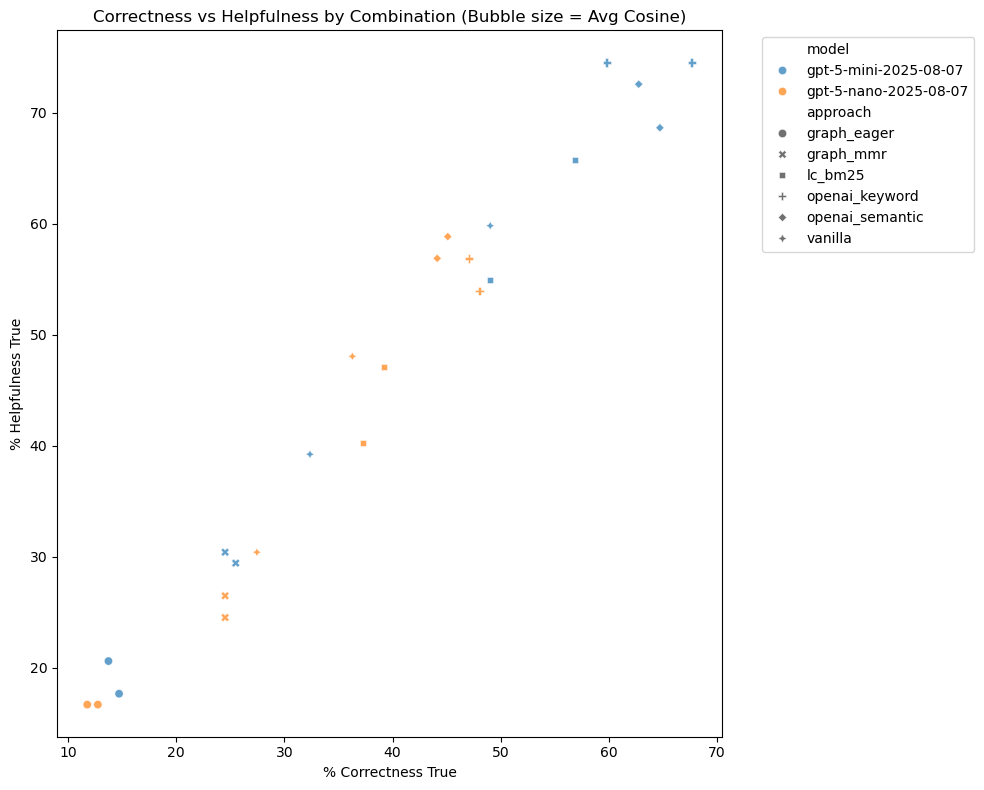

In [10]:
# =======================================
# Annotated Bubble Chart
# =======================================

# Bubble chart: each combination plotted by correctness vs helpfulness
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    data=agg_df,
    x="pct_correctness_true",
    y="pct_helpfulness_true",
    hue="model",
    style="approach",
    sizes=(100, 600),
    alpha=0.7
)
plt.title("Correctness vs Helpfulness by Combination (Bubble size = Avg Cosine)")
plt.xlabel("% Correctness True")
plt.ylabel("% Helpfulness True")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:

# =======================================
# Combined Scoring View
# =======================================

# Create a composite ranking score (normalized 0–1)
from sklearn.preprocessing import MinMaxScaler # type: ignore

scaler = MinMaxScaler()
# agg_df[["score_correctness", "score_helpfulness"]] = scaler.fit_transform(
#     agg_df[["pct_correctness_true", "pct_helpfulness_true"]]
# )
agg_df["averaged_score"] = (agg_df["pct_correctness_true"] + agg_df["pct_helpfulness_true"]) / 2

ranked = agg_df.sort_values("averaged_score", ascending=False)
ranked["rank"] = 0
print(agg_df.columns)

for idx, (i,row) in enumerate(ranked.iterrows()):
    ranked.loc[i, "rank"] = idx
print("\nRanked by Average Correctness and Helpfullness Score:")
display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]])

Index(['approach', 'model', 'top_k', 'avg_meta_total_tokens', 'avg_price_usd',
       'avg_latency_sec', 'true_correctness_count', 'total_correctness_count',
       'true_helpfulness_count', 'total_helpfulness_count',
       'pct_correctness_true', 'pct_helpfulness_true', 'averaged_score'],
      dtype='object')

Ranked by Average Correctness and Helpfullness Score:


,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
12,0,openai_keyword,gpt-5-mini-2025-08-07,3,5.727353,9085.147059,0.018170,67.647059,74.509804,71.078431
16,1,openai_semantic,gpt-5-mini-2025-08-07,3,6.914510,9227.274510,0.018455,62.745098,72.549020,67.647059
13,2,openai_keyword,gpt-5-mini-2025-08-07,7,7.613333,18563.225490,0.037126,59.803922,74.509804,67.156863
17,3,openai_semantic,gpt-5-mini-2025-08-07,7,7.088922,18543.166667,0.037086,64.705882,68.627451,66.666667
9,4,lc_bm25,gpt-5-mini-2025-08-07,7,6.595882,27105.274510,0.054211,56.862745,65.686275,61.274510
21,5,vanilla,gpt-5-mini-2025-08-07,7,8.207451,11208.088235,0.022416,49.019608,59.803922,54.411765
18,6,openai_semantic,gpt-5-nano-2025-08-07,3,5.412157,9141.588235,0.003657,45.098039,58.823529,51.960784
8,7,lc_bm25,gpt-5-mini-2025-08-07,3,5.944118,11752.078431,0.023504,49.019608,54.901961,51.960784
14,8,openai_keyword,gpt-5-nano-2025-08-07,3,4.583137,9101.549020,0.003641,47.058824,56.862745,51.960784
15,9,openai_keyword,gpt-5-nano-2025-08-07,7,5.214510,18561.323529,0.007425,48.039216,53.921569,50.980392


In [12]:
# display(ranked[[
#     "rank", "approach", "model", "top_k", 
#     "pct_correctness_true", "pct_helpfulness_true", "combined_score"
# ]].head(5))

display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]].head(5))

,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
12,0,openai_keyword,gpt-5-mini-2025-08-07,3,5.727353,9085.147059,0.018170,67.647059,74.509804,71.078431
16,1,openai_semantic,gpt-5-mini-2025-08-07,3,6.914510,9227.274510,0.018455,62.745098,72.549020,67.647059
13,2,openai_keyword,gpt-5-mini-2025-08-07,7,7.613333,18563.225490,0.037126,59.803922,74.509804,67.156863
17,3,openai_semantic,gpt-5-mini-2025-08-07,7,7.088922,18543.166667,0.037086,64.705882,68.627451,66.666667
9,4,lc_bm25,gpt-5-mini-2025-08-07,7,6.595882,27105.274510,0.054211,56.862745,65.686275,61.274510


In [13]:
# =======================================
# Combined Latency View
# =======================================

# Create a composite ranking score (normalized 0–1)
from sklearn.preprocessing import MinMaxScaler # type: ignore

scaler = MinMaxScaler()
# agg_df[["score_correctness", "score_helpfulness"]] = scaler.fit_transform(
#     agg_df[["pct_correctness_true", "pct_helpfulness_true"]]
# )
agg_df["averaged_score"] = (agg_df["pct_correctness_true"] + agg_df["pct_helpfulness_true"]) / 2

ranked = agg_df.sort_values("avg_latency_sec", ascending=True)
ranked["rank"] = 0
print(agg_df.columns)

for idx, (i,row) in enumerate(ranked.iterrows()):
    ranked.loc[i, "rank"] = idx
print("\nRanked by Combined Latency Score:")
display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]])

Index(['approach', 'model', 'top_k', 'avg_meta_total_tokens', 'avg_price_usd',
       'avg_latency_sec', 'true_correctness_count', 'total_correctness_count',
       'true_helpfulness_count', 'total_helpfulness_count',
       'pct_correctness_true', 'pct_helpfulness_true', 'averaged_score'],
      dtype='object')

Ranked by Combined Latency Score:


,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
10,0,lc_bm25,gpt-5-nano-2025-08-07,3,3.265196,11770.568627,0.004708,37.254902,40.196078,38.725490
11,1,lc_bm25,gpt-5-nano-2025-08-07,7,3.900784,27114.490196,0.010846,39.215686,47.058824,43.137255
14,2,openai_keyword,gpt-5-nano-2025-08-07,3,4.583137,9101.549020,0.003641,47.058824,56.862745,51.960784
19,3,openai_semantic,gpt-5-nano-2025-08-07,7,5.174804,18679.784314,0.007472,44.117647,56.862745,50.490196
15,4,openai_keyword,gpt-5-nano-2025-08-07,7,5.214510,18561.323529,0.007425,48.039216,53.921569,50.980392
2,5,graph_eager,gpt-5-nano-2025-08-07,3,5.301667,1920.607843,0.000768,12.745098,16.666667,14.705882
18,6,openai_semantic,gpt-5-nano-2025-08-07,3,5.412157,9141.588235,0.003657,45.098039,58.823529,51.960784
12,7,openai_keyword,gpt-5-mini-2025-08-07,3,5.727353,9085.147059,0.018170,67.647059,74.509804,71.078431
8,8,lc_bm25,gpt-5-mini-2025-08-07,3,5.944118,11752.078431,0.023504,49.019608,54.901961,51.960784
3,9,graph_eager,gpt-5-nano-2025-08-07,7,5.950196,1919.215686,0.000768,11.764706,16.666667,14.215686


In [14]:
# =======================================
# Combined Token View
# =======================================

# Create a composite ranking score (normalized 0–1)
from sklearn.preprocessing import MinMaxScaler # type: ignore

scaler = MinMaxScaler()
# agg_df[["score_correctness", "score_helpfulness"]] = scaler.fit_transform(
#     agg_df[["pct_correctness_true", "pct_helpfulness_true"]]
# )
agg_df["averaged_score"] = (agg_df["pct_correctness_true"] + agg_df["pct_helpfulness_true"]) / 2

ranked = agg_df.sort_values("avg_meta_total_tokens", ascending=True)
ranked["rank"] = 0
print(agg_df.columns)

for idx, (i,row) in enumerate(ranked.iterrows()):
    ranked.loc[i, "rank"] = idx
print("\nRanked by Token Score:")
display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]])

Index(['approach', 'model', 'top_k', 'avg_meta_total_tokens', 'avg_price_usd',
       'avg_latency_sec', 'true_correctness_count', 'total_correctness_count',
       'true_helpfulness_count', 'total_helpfulness_count',
       'pct_correctness_true', 'pct_helpfulness_true', 'averaged_score'],
      dtype='object')

Ranked by Token Score:


,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
1,0,graph_eager,gpt-5-mini-2025-08-07,7,6.476961,1902.156863,0.003804,13.725490,20.588235,17.156863
0,1,graph_eager,gpt-5-mini-2025-08-07,3,6.853137,1906.117647,0.003812,14.705882,17.647059,16.176471
3,2,graph_eager,gpt-5-nano-2025-08-07,7,5.950196,1919.215686,0.000768,11.764706,16.666667,14.215686
2,3,graph_eager,gpt-5-nano-2025-08-07,3,5.301667,1920.607843,0.000768,12.745098,16.666667,14.705882
7,4,graph_mmr,gpt-5-nano-2025-08-07,7,5.980784,3199.549020,0.001280,24.509804,26.470588,25.490196
6,5,graph_mmr,gpt-5-nano-2025-08-07,3,6.164804,3207.852941,0.001283,24.509804,24.509804,24.509804
4,6,graph_mmr,gpt-5-mini-2025-08-07,3,7.174804,3225.784314,0.006452,24.509804,30.392157,27.450980
5,7,graph_mmr,gpt-5-mini-2025-08-07,7,8.001569,3226.098039,0.006452,25.490196,29.411765,27.450980
20,8,vanilla,gpt-5-mini-2025-08-07,3,7.870882,5036.960784,0.010074,32.352941,39.215686,35.784314
22,9,vanilla,gpt-5-nano-2025-08-07,3,6.371373,5039.656863,0.002016,27.450980,30.392157,28.921569


In [15]:
# =======================================
# Combined Price View
# =======================================

# Create a composite ranking score (normalized 0–1)
from sklearn.preprocessing import MinMaxScaler # type: ignore

scaler = MinMaxScaler()
# agg_df[["score_correctness", "score_helpfulness"]] = scaler.fit_transform(
#     agg_df[["pct_correctness_true", "pct_helpfulness_true"]]
# )
agg_df["averaged_score"] = (agg_df["pct_correctness_true"] + agg_df["pct_helpfulness_true"]) / 2

ranked = agg_df.sort_values("avg_price_usd", ascending=True)
ranked["rank"] = 0
print(agg_df.columns)

for idx, (i,row) in enumerate(ranked.iterrows()):
    ranked.loc[i, "rank"] = idx
print("\nRanked by Price Score:")
display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]])

Index(['approach', 'model', 'top_k', 'avg_meta_total_tokens', 'avg_price_usd',
       'avg_latency_sec', 'true_correctness_count', 'total_correctness_count',
       'true_helpfulness_count', 'total_helpfulness_count',
       'pct_correctness_true', 'pct_helpfulness_true', 'averaged_score'],
      dtype='object')

Ranked by Price Score:


,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
3,0,graph_eager,gpt-5-nano-2025-08-07,7,5.950196,1919.215686,0.000768,11.764706,16.666667,14.215686
2,1,graph_eager,gpt-5-nano-2025-08-07,3,5.301667,1920.607843,0.000768,12.745098,16.666667,14.705882
7,2,graph_mmr,gpt-5-nano-2025-08-07,7,5.980784,3199.549020,0.001280,24.509804,26.470588,25.490196
6,3,graph_mmr,gpt-5-nano-2025-08-07,3,6.164804,3207.852941,0.001283,24.509804,24.509804,24.509804
22,4,vanilla,gpt-5-nano-2025-08-07,3,6.371373,5039.656863,0.002016,27.450980,30.392157,28.921569
14,5,openai_keyword,gpt-5-nano-2025-08-07,3,4.583137,9101.549020,0.003641,47.058824,56.862745,51.960784
18,6,openai_semantic,gpt-5-nano-2025-08-07,3,5.412157,9141.588235,0.003657,45.098039,58.823529,51.960784
1,7,graph_eager,gpt-5-mini-2025-08-07,7,6.476961,1902.156863,0.003804,13.725490,20.588235,17.156863
0,8,graph_eager,gpt-5-mini-2025-08-07,3,6.853137,1906.117647,0.003812,14.705882,17.647059,16.176471
23,9,vanilla,gpt-5-nano-2025-08-07,7,6.704216,11236.196078,0.004494,36.274510,48.039216,42.156863


In [16]:

combo_1 = {
    "approach": "openai_keyword",
    "model": "gpt-5-mini-2025-08-07",
    "top_k": 7,
}
combo_2 = {
    "approach": "openai_semantic",
    "model": "gpt-5-mini-2025-08-07",
    "top_k": 3,
}

compare_df = df[
    ((df["approach"] == combo_1["approach"]) & 
     (df["model"] == combo_1["model"]) & 
     (df["top_k"] == combo_1["top_k"])) |
    ((df["approach"] == combo_2["approach"]) & 
     (df["model"] == combo_2["model"]) & 
     (df["top_k"] == combo_2["top_k"]))
]

print(f"Subset shape: {compare_df.shape}")
print(compare_df[["approach", "model", "top_k"]].drop_duplicates())

question_compare_df = (
    compare_df.groupby(["question", "approach", "model", "top_k"])
    .agg(
        avg_price_usd=("price_usd", "mean"),
        avg_latency_sec=("total_elapsed_time_sec", "mean"),
        avg_meta_total_tokens=("meta_total_tokens", "mean"),
        true_correctness_count=("judge_answer_correctness_vs_ref", "sum"),
        total_correctness_count=("judge_answer_correctness_vs_ref", "count"),
        true_helpfulness_count=("judge_answer_helpfulness", "sum"),
        total_helpfulness_count=("judge_answer_helpfulness", "count"),
    )
    .reset_index()
)

# Derived percentages
question_compare_df["pct_correctness_true"] = (
    question_compare_df["true_correctness_count"]
    / question_compare_df["total_correctness_count"] * 100
)
question_compare_df["pct_helpfulness_true"] = (
    question_compare_df["true_helpfulness_count"]
    / question_compare_df["total_helpfulness_count"] * 100
)

print("\nQuestion-level results for selected configurations:")
display(
    question_compare_df[[
        "question",
        "approach",
        "model",
        "top_k",
        "avg_latency_sec",
        "avg_meta_total_tokens",
        "avg_price_usd",
        "pct_correctness_true",
        "pct_helpfulness_true",
    ]]
    .sort_values(["question", "approach"])
)


Subset shape: (204, 33)
            approach                  model  top_k
51    openai_keyword  gpt-5-mini-2025-08-07      7
408  openai_semantic  gpt-5-mini-2025-08-07      3

Question-level results for selected configurations:


,question,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true
0,Can you look up electricians in the area for t...,openai_keyword,gpt-5-mini-2025-08-07,7,7.290,16996.5,0.033993,100.0,50.0
1,Can you look up electricians in the area for t...,openai_semantic,gpt-5-mini-2025-08-07,3,4.580,10075.0,0.020150,100.0,50.0
2,Do I need to wear hearing protection when arou...,openai_keyword,gpt-5-mini-2025-08-07,7,4.315,16581.5,0.033163,100.0,100.0
3,Do I need to wear hearing protection when arou...,openai_semantic,gpt-5-mini-2025-08-07,3,4.520,8666.0,0.017332,0.0,100.0
4,Does the Bridgeport take R8 collets?,openai_keyword,gpt-5-mini-2025-08-07,7,7.070,12711.5,0.025423,100.0,100.0
...,...,...,...,...,...,...,...,...,...
97,Where is the spindle brake located on the brid...,openai_semantic,gpt-5-mini-2025-08-07,3,5.320,12043.0,0.024086,100.0,100.0
98,Which direction do I turn the wheel for speed ...,openai_keyword,gpt-5-mini-2025-08-07,7,5.910,15486.0,0.030972,0.0,100.0
99,Which direction do I turn the wheel for speed ...,openai_semantic,gpt-5-mini-2025-08-07,3,5.975,8228.5,0.016457,50.0,100.0
100,Why are there 2 ranges on the speed change fl...,openai_keyword,gpt-5-mini-2025-08-07,7,6.615,23661.0,0.047322,100.0,100.0


In [17]:
combo_1 = {
    "approach": "openai_keyword",
    "model": "gpt-5-mini-2025-08-07",
    "top_k": 7,
}
combo_2 = {
    "approach": "openai_semantic",
    "model": "gpt-5-mini-2025-08-07",
    "top_k": 3,
}

# --- Filter the main dataframe for just these groups ---
compare_df = df[
    ((df["approach"] == combo_1["approach"]) & 
     (df["model"] == combo_1["model"]) & 
     (df["top_k"] == combo_1["top_k"])) |
    ((df["approach"] == combo_2["approach"]) & 
     (df["model"] == combo_2["model"]) & 
     (df["top_k"] == combo_2["top_k"]))
].copy()

print(f"Subset shape: {compare_df.shape}")
print(compare_df[["approach", "model", "top_k"]].drop_duplicates())

# --- Compute per-question correctness ---
question_compare_df = (
    compare_df.groupby(["question", "approach"])
    .agg(
        true_correctness_count=("judge_answer_correctness_vs_ref", "sum"),
        total_correctness_count=("judge_answer_correctness_vs_ref", "count"),
    )
    .reset_index()
)

# Binary 1/0 correctness per question (100% = True)
question_compare_df["is_correct"] = (
    question_compare_df["true_correctness_count"]
    / question_compare_df["total_correctness_count"]
) == 1.0

# --- Pivot into side-by-side comparison ---
pivot_correct = question_compare_df.pivot_table(
    index="question", columns="approach", values="is_correct"
).reset_index()

# Drop questions not answered by both
pivot_correct = pivot_correct.dropna(subset=[combo_1["approach"], combo_2["approach"]])

# --- Determine which approach "won" each question ---
pivot_correct["winner"] = pivot_correct.apply(
    lambda x: (
        combo_1["approach"]
        if (x[combo_1["approach"]] and not x[combo_2["approach"]])
        else (combo_2["approach"]
              if (x[combo_2["approach"]] and not x[combo_1["approach"]])
              else "tie")
    ),
    axis=1,
)

# --- Split into categories ---
questions_keyword_won = pivot_correct[pivot_correct["winner"] == combo_1["approach"]]
questions_semantic_won = pivot_correct[pivot_correct["winner"] == combo_2["approach"]]
questions_tied = pivot_correct[pivot_correct["winner"] == "tie"]

# --- Display tables ---
print(f"\n{combo_1['approach']} got right where {combo_2['approach']} missed:")
display(questions_keyword_won[["question", combo_1["approach"], combo_2["approach"]]])

print(f"\n{combo_2['approach']} got right where {combo_1['approach']} missed:")
display(questions_semantic_won[["question", combo_1["approach"], combo_2["approach"]]])

print(f"\nQuestions both got right or both missed:")
display(questions_tied[["question", combo_1["approach"], combo_2["approach"]]])

# --- Summary counts ---
summary_counts = pivot_correct["winner"].value_counts().reset_index()
summary_counts.columns = ["winner", "num_questions"]
print("\nSummary of question-level outcomes:")
display(summary_counts)



Subset shape: (204, 33)
            approach                  model  top_k
51    openai_keyword  gpt-5-mini-2025-08-07      7
408  openai_semantic  gpt-5-mini-2025-08-07      3

openai_keyword got right where openai_semantic missed:


approach,question,openai_keyword,openai_semantic
1,Do I need to wear hearing protection when arou...,1.0,0.0
28,Is it okay to wear gold around the bridgeport ...,1.0,0.0
41,What is the difference between high-low switch...,1.0,0.0



openai_semantic got right where openai_keyword missed:


approach,question,openai_keyword,openai_semantic
8,How do I lock the spindle on the bridgeport mill?,0.0,1.0
11,How do I remove the nose piece of the bridgepo...,0.0,1.0
13,How do I set the maximum depth for the bridgep...,0.0,1.0
20,I am trying to mount the Spindle Guard onto th...,0.0,1.0



Questions both got right or both missed:


approach,question,openai_keyword,openai_semantic
0,Can you look up electricians in the area for t...,1.0,1.0
2,Does the Bridgeport take R8 collets?,1.0,1.0
3,How can I change the e-head speed of the bridg...,1.0,1.0
4,How do I change the spindle speed on the bridg...,1.0,1.0
5,How do I change the torque of the lever for th...,0.0,0.0
6,How do I connect my power supply to the bridge...,1.0,1.0
7,How do I know the brake shoe needs replacement...,0.0,0.0
9,How do I move the Ram Slide on the bridgeport ...,1.0,1.0
10,How do I put the quill in hand feed mode on th...,1.0,1.0
12,How do I replace the timing belt of the brideg...,1.0,1.0



Summary of question-level outcomes:


,winner,num_questions
0,tie,44
1,openai_semantic,4
2,openai_keyword,3
